# Bài kiểm tra thực hành — Lập trình phân tích dữ liệu

**Họ và tên:** …………………………  
**MSSV:** …………  
**Lớp:** …………

> Đọc đề trong thư mục `de_thi/`. Làm mỗi câu trong đúng ô bên dưới — có thể thêm ô nếu cần.  
> Trước khi nộp: **Restart & Run All**, lưu file thành `MSSV_HoTen.ipynb`.

In [1]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_DIR = Path('../du_lieu')  
assert (DATA_DIR / 'don_hang.csv').exists(), 'Không tìm thấy dữ liệu — kiểm tra lại DATA_DIR'

## Phần A — Python thuần: xử lý tập tin văn bản (2,0 điểm)
*Không dùng pandas trong phần này.*

### A1 (1,0 đ) Lọc dòng hợp lệ bằng regex · ghi `dong_loi.txt`

In [2]:
# A1
MAU = re.compile(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2} \| DH\d{5} \| '
                 r'(GIAO_THANH_CONG|THAT_BAI|HOAN_TRA) \| shipper=(SP\d{2})')
hop_le, loi = [], []
folder = Path('../du_lieu')
with open(folder/'nhat_ky_giao_hang.txt', 'r', encoding='utf-8-sig') as f:
    for line in f:
        line = line.rstrip('\n')
        if line.strip() == '' or line.startswith('#'):
            continue
        mau = MAU.fullmatch(line)
        hop_le.append(line) if mau else loi.append(line)
with open(folder/'loi.txt', 'w', encoding='utf-8-sig') as w:
    w.write('\n'.join(loi) + '\n')

print('So dong loi:', len(loi))
print('So dong hop le:', len(hop_le))
    

So dong loi: 42
So dong hop le: 880


### A2 (1,0 đ) Hàm `ti_le_thanh_cong(cac_dong, toi_thieu=20)`

Viết hàm ti_le_thanh_cong(cac_dong, toi_thieu=20) nhận danh sách dòng hợp lệ và trả về dict {mã
shipper: tỉ lệ} , trong đó tỉ lệ = số lần GIAO_THANH_CONG ÷ tổng số lần giao của shipper đó. Chỉ đưa
vào kết quả những shipper có ít nhất toi_thieu lần giao.
Gọi hàm với tham số mặc định, in tỉ lệ của từng shipper (3 chữ số thập phân) và cho biết shipper có tỉ
lệ thấp nhất.

In [3]:
# A2
#ti le = so lan GIAO_THANH_CONG + tong so lan giao cua shipper
from collections import Counter
def ti_le_thanh_cong(cac_dong, toi_thieu=20):
    success = Counter()
    total = Counter()
    for d in cac_dong:
        trang_thai, sp = MAU.fullmatch(d).groups()
        total[sp] +=1
        if trang_thai == 'GIAO_THANH_CONG':
            success[sp] +=1
    return {sp: success[sp] / n for sp, n in total.items() if n >= toi_thieu}

result = ti_le_thanh_cong(hop_le)
if result:
    for sp in sorted(result):
        print(f'{sp}: {result[sp]:.3f}')
    min_sp = min(result, key=result.get)
print(f'\nShipper tỉ lệ thấp nhất (>= 20 đơn): {min_sp} — {result[min_sp]:.1%}')



SP01: 0.904
SP02: 0.910
SP03: 0.774
SP04: 0.886
SP05: 0.946
SP06: 0.910
SP07: 0.670
SP08: 0.911
SP09: 0.904
SP10: 0.888

Shipper tỉ lệ thấp nhất (>= 20 đơn): SP07 — 67.0%


## Phần B — Pandas: đọc, làm sạch và ghép dữ liệu (3,0 điểm)

### B1 (0,5 đ) Đọc & khảo sát dữ liệu

In [22]:
# B1


from pandas.core.frame import DataFrame


df_ship = pd.read_csv(folder/'don_hang.csv')
print('5 dong dau cua file don hang:\n', df_ship.head().to_string())
df_cus = pd.read_excel(folder/'khach_hang.xlsx')
df_cus = pd.DataFrame(df_cus)
print(df_cus)

df_ship['ngay_dat'] = pd.to_datetime(df_ship['ngay_dat'], format='%d/%m/%Y')

print('Kich thuoc cua bang don hang:', df_ship.shape)
print('Kich thuoc cua bang khach hang:', df_cus.shape)

print('So gia tri thieu cua cac cot co gia tri thieu:\n', df_ship.isna().sum())

5 dong dau cua file don hang:
     ma_don    ngay_dat   ma_kh    thanh_pho        danh_muc  don_gia  so_luong phuong_thuc_tt  danh_gia
0  DH00001  01/01/2025  KH0375      Cần Thơ       Thực phẩm    22000       2.0       Tiền mặt       3.0
1  DH00002  01/01/2025  KH0277       Hà Nội        Gia dụng   402000       1.0   Chuyển khoản       5.0
2  DH00003  01/01/2025  KH0374       Hà Nội  Văn phòng phẩm    16000       5.0   Chuyển khoản       NaN
3  DH00004  01/01/2025  KH0104       Hà Nội         Mỹ phẩm   261000       2.0       Tiền mặt       5.0
4  DH00005  01/01/2025  KH0338  Hồ Chí Minh        Gia dụng   560000       2.0   Chuyển khoản       3.0
      ma_kh gioi_tinh  nam_sinh hang_thanh_vien ngay_dang_ky
0    KH0001        Nữ      1967             Bạc   2024-02-04
1    KH0002       Nam      1972             Bạc   2024-06-10
2    KH0003        Nữ      1989          Thường   2023-11-19
3    KH0004        Nữ      1997          Thường   2023-10-26
4    KH0005        Nữ      1990         

### B2 (1,5 đ) Làm sạch theo đúng 4 bước

In [23]:
# B2 — bước 1: bỏ dòng trùng 
n = df_ship.drop_duplicates()
print('So dong con lai sau khi loai trung:', len(n))

So dong con lai sau khi loai trung: 2400


In [24]:
# B2 — bước 2: chuẩn hoá thanh_pho
df_ship['thanh_pho'] = df_ship['thanh_pho'].str.strip().str.title()
print(df_ship['thanh_pho'].value_counts())


thanh_pho
Hồ Chí Minh    784
Hà Nội         758
Đà Nẵng        359
Cần Thơ        287
Huế            248
Name: count, dtype: int64


In [25]:
# B2 — bước 3: bỏ so_luong > 100, giữ dòng trống
df_ship = df_ship[~(df_ship['so_luong'] > 100)]
print(len(df_ship))

2427


In [26]:
# B2 — bước 4: điền so_luong bằng trung vị theo danh_muc
trung_vi = df_ship.groupby('danh_muc')['so_luong'].transform(lambda x: x.median())
df_ship['so_luong'] = df_ship['so_luong'].fillna(trung_vi).astype(int)
print('Trung vi so luong theo tung danh muc:\n', df_ship.groupby('danh_muc')['so_luong'].median()) 

Trung vi so luong theo tung danh muc:
 danh_muc
Gia dụng          2.0
Mỹ phẩm           3.0
Thực phẩm         3.0
Văn phòng phẩm    4.0
Đồ uống           4.0
Name: so_luong, dtype: float64


### B3 (1,0 đ) Ghép bảng & tính `thanh_tien`

In [47]:
# B3
kh = pd.read_excel(folder/'khach_hang.xlsx', sheet_name='khach_hang')
htv = pd.read_excel(folder/'khach_hang.xlsx', sheet_name='hang_thanh_vien')
kh_merge = pd.merge(kh, htv, on='hang_thanh_vien', how='left')
df = pd.merge(df_ship, kh_merge, on='ma_kh', how='left')
print('So dong cua df:', len(df))
df['hang_thanh_vien'] = df['hang_thanh_vien'].fillna('Vãng lai')
df['chiet_khau'] = df['chiet_khau'].fillna(0)
vang_lai = df['hang_thanh_vien'].isna().sum()
print('So dong vang lai:', vang_lai)
don_theo_hang = df.groupby('hang_thanh_vien')['so_luong'].count()
df['thanh_tien'] = df['so_luong'] * df['don_gia'] * (1 - df['chiet_khau'])
print('So don theo hang:\n', don_theo_hang)
print(f'Tong doanh thu:, {df['thanh_tien'].sum():,}')

So dong cua df: 2427
So dong vang lai: 0
So don theo hang:
 hang_thanh_vien
Bạc          716
Thường      1126
Vàng         395
Vãng lai     190
Name: so_luong, dtype: int64
Tong doanh thu:, 823,425,850.0


## Phần C — Phân tích tổng hợp (2,0 điểm)

### C1 (1,0 đ) Doanh thu theo thành phố × danh mục

In [73]:
# C1
doanh_thu = pd.pivot_table(df, values='thanh_tien', index='thanh_pho', columns='danh_muc', aggfunc='sum', margins=True, margins_name='Total')
print(doanh_thu.to_string())

thanh_pho = doanh_thu.drop(index='Total')['Total']
print('Thanh pho co doanh thu lon nhat:', thanh_pho.idxmax(), ',', 'doanh thu:', thanh_pho.max().round(0))
danh_muc = doanh_thu.loc['Total'].drop('Total')
print('Danh muc co doanh thu cao nhat:', danh_muc.idxmax(), ',', 'doanh thu:', danh_muc.max())
rev_no_total = doanh_thu.drop(index='Total', columns='Total')
print('Danh muc dan dau tung thanh pho:\n', rev_no_total.idxmax(axis=1))

danh_muc        Gia dụng      Mỹ phẩm    Thực phẩm  Văn phòng phẩm     Đồ uống        Total
thanh_pho                                                                                  
Cần Thơ       16564800.0   17073050.0   36016050.0       3077150.0   9968800.0   82699850.0
Huế           10876150.0   15179200.0   25429800.0       3130650.0   9311550.0   63927350.0
Hà Nội        51116100.0  131918850.0   42655350.0      14391450.0  28676100.0  268757850.0
Hồ Chí Minh   66261800.0  132061350.0   50977800.0      15693850.0  24661450.0  289656250.0
Đà Nẵng       36853450.0   34526450.0   28361350.0       7585050.0  11058250.0  118384550.0
Total        181672300.0  330758900.0  183440350.0      43878150.0  83676150.0  823425850.0
Thanh pho co doanh thu lon nhat: Hồ Chí Minh , doanh thu: 289656250.0
Danh muc co doanh thu cao nhat: Mỹ phẩm , doanh thu: 330758900.0
Danh muc dan dau tung thanh pho:
 thanh_pho
Cần Thơ        Thực phẩm
Huế            Thực phẩm
Hà Nội           Mỹ phẩm
Hồ Chí Min

**Trả lời C1:** Thành phố doanh thu cao nhất là … ; danh mục dẫn đầu từng thành phố: …

### C2 (1,0 đ) Doanh thu theo tháng & tăng trưởng

In [96]:
# C2
df['month'] = df['ngay_dat'].dt.month
monthly = df.groupby('month')['thanh_tien'].sum() / 1e8
growth = monthly.pct_change() * 100
print('Doanh thu theo tung thang:\n', monthly)
print('Tang truong theo tung thang:\n', growth)
print('Thang tang truong nhieu nhat:', growth.idxmax(), ',', 'toc do tang truong:', growth.max().round(2))

Doanh thu theo tung thang:
 month
1    1.373424
2    0.921861
3    1.410932
4    1.315867
5    1.299038
6    1.913137
Name: thanh_tien, dtype: float64
Tang truong theo tung thang:
 month
1          NaN
2   -32.878630
3    53.052521
4    -6.737676
5    -1.279004
6    47.273424
Name: thanh_tien, dtype: float64
Thang tang truong nhieu nhat: 3 , toc do tang truong: 53.05


**Trả lời C2:** Tháng tăng trưởng mạnh nhất là … . Không nên kết luận đó là tháng kinh doanh tốt nhất vì …

## Phần D — Trực quan hoá (1,5 điểm)

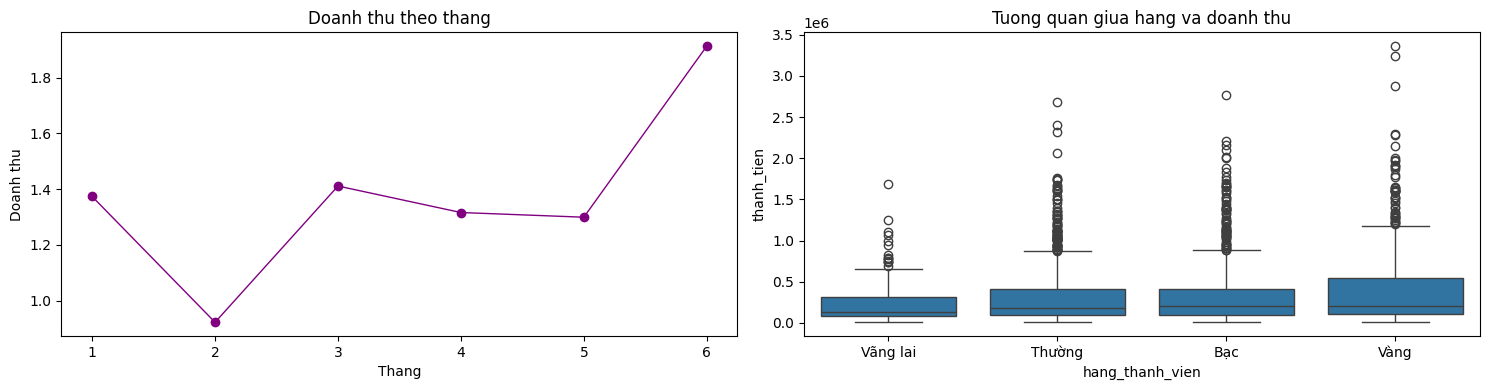

In [102]:
# D
plt.subplots(1,2, figsize=(15,4))
plt.subplot(1,2,1)
plt.plot(monthly.index, monthly.values, marker='o', color='purple', linewidth=1)
plt.title('Doanh thu theo thang')
plt.xlabel('Thang')
plt.ylabel('Doanh thu')
plt.subplot(1,2,2)
sns.boxplot(x='hang_thanh_vien', y='thanh_tien', data=df, order=['Vãng lai', 'Thường', 'Bạc', 'Vàng'])
plt.title('Tuong quan giua hang va doanh thu')
plt.tight_layout()
plt.savefig('ket_qua.png', dpi=150)
plt.show()

**Nhận xét biểu đồ hộp:** …

## Phần E — Thống kê suy luận (1,5 điểm) · α = 0,05

### E1 (1,0 đ) Khách Vàng vs khách Thường

- **H0:** …
- **H1:** …

In [13]:
# E1


**Kết luận E1:** …

### E2 (0,5 đ) Phương thức thanh toán × thành phố

In [14]:
# E2


**Kết luận E2:** …